In [1]:
import pandas as pd

df = pd.DataFrame({
    "temperature": [10, 7, 4, 0],
    "sales": [30, 50, 60, 80]
})

display(df)

,temperature,sales
0,10,30
1,7,50
2,4,60
3,0,80


In [2]:
a = -4
b = 80

for i in range(len(df)):
    x = df.loc[i, "temperature"]
    y = df.loc[i, "sales"]
    pred = a * x + b
    error = y - pred

    print(f"X={x}, 실제값={y}, 예측값={pred}, 오차={pred}-{y}={error}")
    print("="*30)

X=10, 실제값=30, 예측값=40, 오차=40-30=-10
X=7, 실제값=50, 예측값=52, 오차=52-50=-2
X=4, 실제값=60, 예측값=64, 오차=64-60=-4
X=0, 실제값=80, 예측값=80, 오차=80-80=0


In [3]:
import torch

# x_tensor: 입력값 X(기온), y_tensor: 정답 Y(판매량)
x_tensor = torch.tensor(df["temperature"].values, dtype=torch.float32)
print(f"x_tensor = {x_tensor}")
y_tensor = torch.tensor(df["sales"].values, dtype=torch.float32)
print(f"y_tensor = {y_tensor}")

# a: 직선의 기울기, b: 직선의 절편
# requires_grad=True: PyTorch에게 이 값의 미분(Gradient) 계산하라고 알려 주는 설정
a = torch.tensor(-4.0, requires_grad=True)
print(a)
b = torch.tensor(80.0, requires_grad=True)
print(b)

learning_rate = 0.001       # 한번에 얼마나 크게 a, b를 수정할지 정하는 값(보폭)
epochs = 1000               # 전체 데이터를 몇 번 반복해서 학습할지 정하는 값
cost_history = []           # 매 epoch의 Cost를 저장할 리스트 (그래프로 그리기 위함)

# 학습 전후를 비교하려고, 시작 시점의 a, b와 Cost를 기억해 두기
initial_a = a.item()
initial_b = b.item()
with torch.no_grad():
    initial_cost = (torch.mean((y_tensor - (a * x_tensor + b)) ** 2)).item()
print(f"학습 전 a={initial_a:.4f}, b={initial_b:.4f}, Cost={initial_cost:.4f}")

x_tensor = tensor([10.,  7.,  4.,  0.])
y_tensor = tensor([30., 50., 60., 80.])
tensor(-4., requires_grad=True)
tensor(80., requires_grad=True)
학습 전 a=-4.0000, b=80.0000, Cost=30.0000


In [4]:
for epoch in range(epochs):
    # pred: 현재 a, b로 계산한 예측값 (H(x) = a * x + b)
    pred = a * x_tensor + b

    # error는 기존 강의 정의 그대로 사용
    error = y_tensor - pred

    # cost: 현재 예측이 실제값과 얼마나 차이나는지 나타내는 Cost
    # Cost = 오차 제곱 평균
    cost = torch.mean(error ** 2)

    # cost.backward(): PyTorch가 a, b에 대한 Gradient를 자동으로 계산
    cost.backward()

    # a, b 값을 직접 수정할 때는 계산 그래프에 기록하지 않음
    with torch.no_grad():
        a -= learning_rate * a.grad # a.grad: PyTorch가 계산한 a의 Gradient
        b -= learning_rate * b.grad # b.grad: PyTorch가 계산한 b의 Gradient
    
    # PyTorch는 Gradient를 자동으로 누적하므로 매 epoch마다 초기화 필요
    a.grad.zero_()
    b.grad.zero_()

    cost_history.append(cost.item())

    if epoch % 100 == 0:
        print(f"epoch={epoch}, Cost={cost.item():.4f}, a={a.item():.4f}, b={b.item():.4f}")

epoch=0, Cost=30.0000, a=-4.0650, b=79.9920
epoch=100, Cost=4.4137, a=-4.7788, b=79.9333
epoch=200, Cost=4.4044, a=-4.7828, b=79.9635
epoch=300, Cost=4.3963, a=-4.7864, b=79.9917
epoch=400, Cost=4.3891, a=-4.7898, b=80.0183
epoch=500, Cost=4.3829, a=-4.7930, b=80.0431
epoch=600, Cost=4.3774, a=-4.7960, b=80.0664
epoch=700, Cost=4.3725, a=-4.7988, b=80.0881
epoch=800, Cost=4.3683, a=-4.8014, b=80.1085
epoch=900, Cost=4.3646, a=-4.8038, b=80.1276


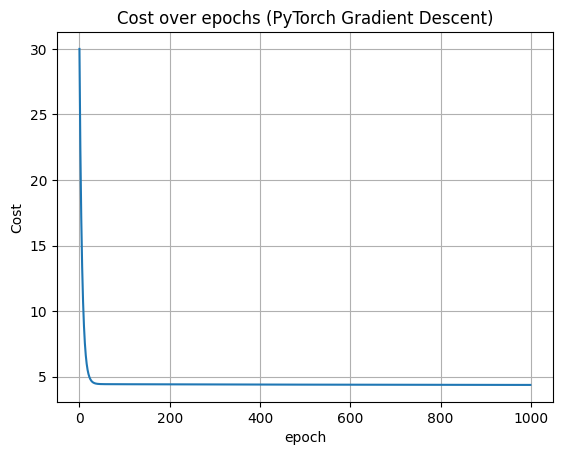

In [5]:
import matplotlib.pyplot as plt

plt.figure()        # 새 그래프 판 만들기
# x축 : epoch 번호(0, 1, 2, ...), y축 : 그 epoch의 Cost
# range(len(cost_history)) 는 0부터 저장된 Cost 개수만큼의 번호를 만들어 줍니다.
plt.plot(range(len(cost_history)), cost_history)
plt.title("Cost over epochs (PyTorch Gradient Descent)")    # 그래프 제목
plt.xlabel("epoch")     # x축 이름 : 반복 횟수
plt.ylabel("Cost")      # y축 이름 : Cost
plt.grid(True)          # 눈금선 표시
plt.show()              # 그래프 화면에 출력

In [6]:
# 학습 전 값: 12번 셀에서 학습 시작 전에 저장해 둔 initial_a, initial_b, initial_cost 를 사용합니다.
# 학습 후 값: 학습 반복문이 끝난 뒤 남아 있는 a, b 가 곧 학습된 값 (.item()으로 숫자 값을 꺼냄)
final_a = a.item()
final_b = b.item()
with torch.no_grad():
    final_cost = (torch.mean((y_tensor - (a * x_tensor + b)) ** 2)).item()

print("학습 전")
print(f"a = {initial_a:.4f}")
print(f"b = {initial_b:.4f}")
print(f"Cost = {initial_cost:.4f}")

print("\n학습 후")
print(f"a = {final_a:.4f}")
print(f"b = {final_b:.4f}")
print(f"Cost = {final_cost:.4f}")

학습 전
a = -4.0000
b = 80.0000
Cost = 30.0000

학습 후
a = -4.8061
b = 80.1454
Cost = 4.3613


In [7]:
final_a = a.item()
final_b = b.item()

new_x = 5
predicted_y = final_a * new_x + final_b

print(f"학습된 식: y = {final_a:.2f}X + {final_b:.2f}")
print(f"기온이 {new_x}도일 때 예상 판매량: {predicted_y:.2f}개")

학습된 식: y = -4.81X + 80.15
기온이 5도일 때 예상 판매량: 56.11개


In [8]:
def run_gradient_descent(learning_rate, epochs):
    """
    ---- run_gradient_descent 함수 설명 ----
    입력값:
        learning_rate : 한 번에 얼마나 크게 수정할지 정하는 값(보폭)
        epochs        : 전체 학습을 몇 번 반복할지 정하는 값
    반환값:
        최종 a, 최종 b, 최종 Cost
    (12번의 PyTorch 학습 코드를, learning_rate를 바꿔 실험할 수 있게 함수로 묶은 것입니다.)
    ---------------------------------------
    항상 같은 출발선(Y = -4X + 80)에서 시작
    """
    a = torch.tensor(-4.0, requires_grad=True)
    b = torch.tensor(80.0, requires_grad=True)

    for epoch in range(epochs):
        pred = a * x_tensor + b
        error = y_tensor - pred         # error = 실제값 - 예측값
        cost = torch.mean(error ** 2)   # Cost = 오차 제곱 평균

        cost.backward()                 # Gradient 자동 계산
        with torch.no_grad():
            a -= learning_rate * a.grad
            b -= learning_rate * b.grad
        a.grad.zero_()                  # 다음 반복을 위해 Gradient 초기화
        b.grad.zero_()

        # 안전장치 : Cost 가 너무 커지면(발산) 더 돌려봐야 의미가 없으므로 즉시 중단
        if cost.item() > 1000000:
            print("Cost가 너무 커져 학습이 불안정. Learning Rate가 너무 클 수 있음.")
            return a.item(), b.item(), cost.item()
    
    return a.item(), b.item(), cost.item()  # 무사히 끝나면 최종 a, b, Cost 반환

In [9]:
# 여러 learning_rate를 한꺼번에 비교해 봅니다. (큰 값 -> 작은 값 순서)
learning_rates = [0.1, 0.01, 0.001, 0.0001]

for lr in learning_rates:
    final_a, final_b, final_cost = run_gradient_descent(lr, 1000)
    print(f"learning_rate={lr}, 최종 Cost={final_cost:.4f}")
    print("-" * 40)

Cost가 너무 커져 학습이 불안정. Learning Rate가 너무 클 수 있음.
learning_rate=0.1, 최종 Cost=4147874.0000
----------------------------------------
learning_rate=0.01, 최종 Cost=4.3379
----------------------------------------
learning_rate=0.001, 최종 Cost=4.3613
----------------------------------------
learning_rate=0.0001, 최종 Cost=4.4137
----------------------------------------
